# Chapter 19 - Distributions and Foliations

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `490-514`.

**Chapter Goal.** Understand when a field of tangent `k`-planes comes from actual `k`-dimensional integral manifolds, and how the Frobenius theorem turns involutive distributions into foliations, Lie subgroups, and local PDE solutions.

A rank-`k` distribution assigns a `k`-dimensional subspace `D_p` of `T_pM` at every point. An integral manifold is a submanifold whose tangent spaces are exactly those subspaces. The chapter's main tension is that plane fields can twist in a way that no integral manifold can follow. The obstruction is the Lie bracket: if vector fields tangent to the distribution bracket into a direction outside the distribution, the attempted surface is forced to move in a missing direction.

The notebook builds the chapter around this obstruction and its resolution: bracket tests, annihilating 1-forms, the Frobenius flat-chart theorem, global leaves of a foliation, Lie subgroups from Lie subalgebras, and compatibility conditions for overdetermined PDE systems.

## Visual Storyboard

| Chapter idea | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- |
| integrability obstruction | non-involutive plane field in `R^3` | SymPy, Matplotlib | bracket escapes the proposed tangent planes | bracket vector not in span |
| 1-form criterion | annihilator `alpha = dz - y dx` | SymPy, Matplotlib | `d alpha` does not annihilate the kernel | `d alpha(X,Y) = 1` |
| Frobenius flat chart | integrable distribution tangent to `z - xy = constant` | SymPy, Matplotlib | leaves become coordinate slices in `(x,y,z-xy)` | bracket zero and chart Jacobian nonzero |
| local and global leaves | plaque/foliation diagrams | NetworkX, Matplotlib | local slices glue into maximal connected leaves | graph and slice checks |
| Lie subalgebra to subgroup | left-invariant line fields on a torus model | NumPy, Matplotlib | rational and irrational slopes as immersed subgroup leaves | slope/wrapping data |
| PDE compatibility | graph surfaces for compatible/incompatible systems | SymPy, Matplotlib | cross-derivative/bracket condition | compatible obstruction zero; incompatible nonzero |

The graphics are paired with symbolic checks because the Frobenius theorem is a theorem about a condition, not just about pictures of leaves.

## Setup

Artifacts are saved under `artifacts/chapter-19-distributions-and-foliations/`. The examples use small coordinate models, matching the local nature of the Frobenius theorem.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
if BOOK_ROOT.name != "Introduction-to-Smooth-Manifolds":
    BOOK_ROOT = next(path for path in [BOOK_ROOT, *BOOK_ROOT.parents] if path.name == "Introduction-to-Smooth-Manifolds")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-19-distributions-and-foliations"
UNIT_TITLE = "Distributions and Foliations"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifacts: list[Path] = []
check_paths: list[Path] = []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def artifact_record(path: Path) -> dict[str, object]:
    return {
        "path": str(path.relative_to(BOOK_ROOT)).replace("\\", "/"),
        "bytes": path.stat().st_size,
    }

def lie_bracket(X, Y, coords):
    return [sp.simplify(sum(X[j] * sp.diff(Y[i], coords[j]) - Y[j] * sp.diff(X[i], coords[j]) for j in range(len(coords)))) for i in range(len(coords))]

print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifact root: artifacts\chapter-19-distributions-and-foliations


## Library Routing

SymPy handles bracket, annihilator, Jacobian, and PDE compatibility checks exactly. Matplotlib handles local plane-field, surface, torus-square, and PDE surface diagrams. NetworkX is used for proof and gluing structure, where the relevant object is a relation among local charts and leaves.

## 1. The Obstruction: A Bracket Escapes The Plane Field

The source chapter's first warning example is a rank-2 distribution in `R^3` spanned by

`X = partial_x + y partial_z`, and `Y = partial_y`.

If an integral surface passed through the origin, flows of `X` and `Y` would try to sweep out a patch in the `xy` directions. But their commutator is vertical, and that vertical direction is not in the original plane field. The symbolic bracket calculation catches the obstruction.

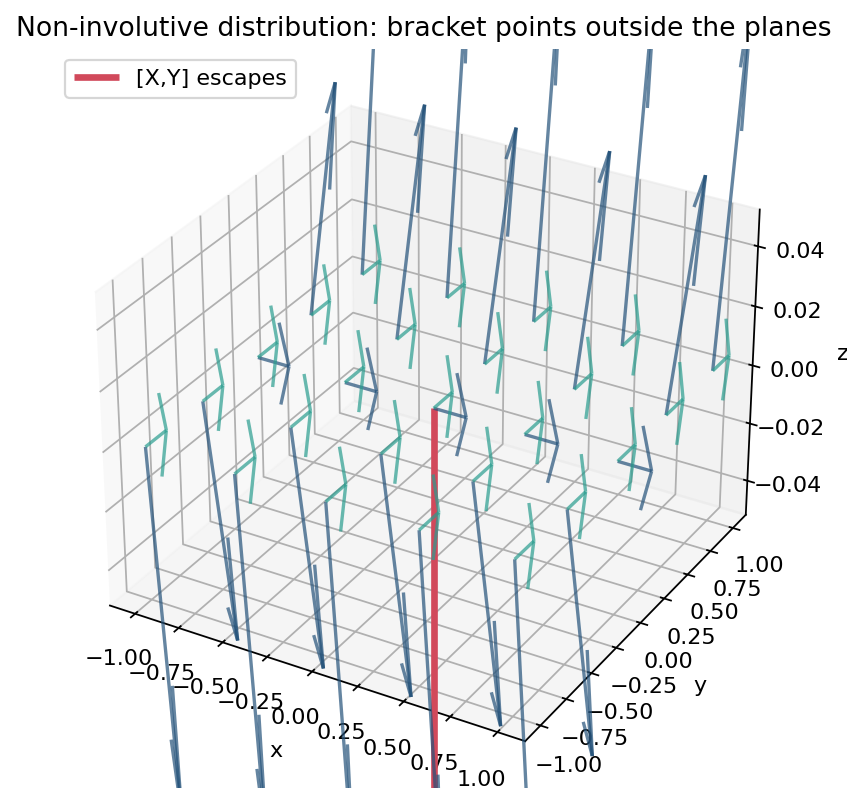

In [2]:
x, y, z = sp.symbols("x y z", real=True)
coords = (x, y, z)
X_bad = [1, 0, y]
Y_bad = [0, 1, 0]
bracket_bad = lie_bracket(X_bad, Y_bad, coords)

a, b = sp.symbols("a b")
span_solution_bad = sp.solve(
    [
        sp.Eq(a * X_bad[0] + b * Y_bad[0], bracket_bad[0]),
        sp.Eq(a * X_bad[1] + b * Y_bad[1], bracket_bad[1]),
        sp.Eq(a * X_bad[2] + b * Y_bad[2], bracket_bad[2]),
    ],
    (a, b),
    dict=True,
)
bracket_in_span_bad = len(span_solution_bad) > 0

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
xs = np.linspace(-1, 1, 5)
ys = np.linspace(-1, 1, 5)
Xg, Yg = np.meshgrid(xs, ys)
Zg = np.zeros_like(Xg)
ax.quiver(Xg, Yg, Zg, np.ones_like(Xg), np.zeros_like(Xg), Yg, length=0.18, normalize=True, color="#24527a", alpha=0.7)
ax.quiver(Xg, Yg, Zg, np.zeros_like(Xg), np.ones_like(Xg), np.zeros_like(Xg), length=0.18, normalize=True, color="#2a9d8f", alpha=0.7)
ax.quiver([0], [0], [0], [0], [0], [-1], length=0.7, color="#d1495b", linewidth=3, label="[X,Y] escapes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Non-involutive distribution: bracket points outside the planes")
ax.legend(loc="upper left")
obstruction_path = save_matplotlib(fig, FIGURES / "noninvolutive-plane-field-bracket-obstruction.png")
plt.close(fig)
artifacts.append(obstruction_path)

obstruction_check = save_json(
    {
        "X": [str(v) for v in X_bad],
        "Y": [str(v) for v in Y_bad],
        "bracket": [str(v) for v in bracket_bad],
        "bracket_in_span": bracket_in_span_bad,
    },
    CHECKS / "noninvolutive-plane-field-bracket-obstruction.json",
)
check_paths.append(obstruction_check)
display_artifact(obstruction_path, width=760)

## 2. The Same Obstruction With A Defining 1-Form

The distribution above is the kernel of the 1-form `alpha = dz - y dx`. The 1-form criterion says that a distribution is involutive precisely when the exterior derivative of every local defining form annihilates the distribution.

Here `d alpha = dx wedge dy`, and evaluating it on the spanning fields gives `1`. That single nonzero number is the 1-form version of the escaping bracket.

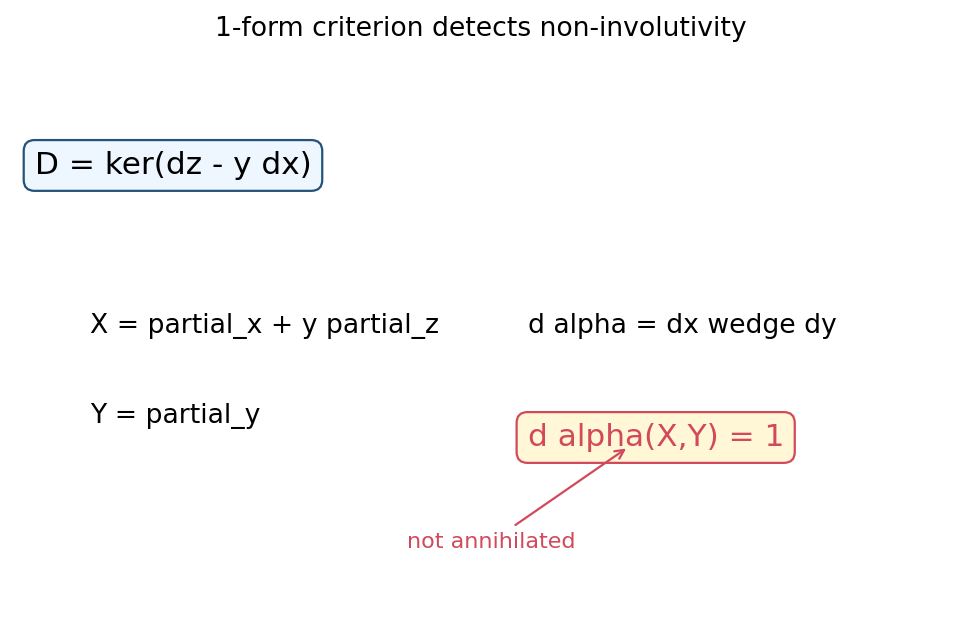

In [3]:
# For alpha = dz - y dx, d alpha = dx wedge dy.
def two_form_dx_wedge_dy(U, V):
    return sp.simplify(U[0] * V[1] - U[1] * V[0])

d_alpha_on_bad = two_form_dx_wedge_dy(X_bad, Y_bad)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.axis("off")
ax.text(0.02, 0.78, "D = ker(dz - y dx)", fontsize=14, bbox={"boxstyle": "round,pad=0.35", "fc": "#eef6ff", "ec": "#24527a"})
ax.text(0.08, 0.50, "X = partial_x + y partial_z", fontsize=12)
ax.text(0.08, 0.34, "Y = partial_y", fontsize=12)
ax.text(0.55, 0.50, "d alpha = dx wedge dy", fontsize=12)
ax.text(0.55, 0.30, "d alpha(X,Y) = 1", fontsize=14, color="#d1495b", bbox={"boxstyle": "round,pad=0.35", "fc": "#fff7d6", "ec": "#d1495b"})
ax.annotate("not annihilated", xy=(0.66, 0.30), xytext=(0.42, 0.12), arrowprops={"arrowstyle": "->", "color": "#d1495b"}, color="#d1495b")
ax.set_title("1-form criterion detects non-involutivity")
form_path = save_matplotlib(fig, FIGURES / "one-form-criterion-noninvolutive-check.png")
plt.close(fig)
artifacts.append(form_path)

form_check = save_json(
    {
        "alpha": "dz - y dx",
        "d_alpha": "dx wedge dy",
        "d_alpha_on_XY": str(d_alpha_on_bad),
        "annihilates_distribution": bool(d_alpha_on_bad == 0),
    },
    CHECKS / "one-form-criterion-noninvolutive-check.json",
)
check_paths.append(form_check)
display_artifact(form_path, width=740)

## 3. Frobenius In A Flat Chart: Leaves `z - xy = constant`

Now compare the non-involutive example with an integrable one. Let

`V = partial_x + y partial_z`, and `W = partial_y + x partial_z`.

These fields are tangent to the level surfaces of `w = z - xy`. Their bracket is zero, and the coordinate change `(u,v,w) = (x,y,z-xy)` turns the distribution into the span of `partial_u` and `partial_v`. This is exactly the local flat-chart conclusion of Frobenius in a concrete coordinate model.

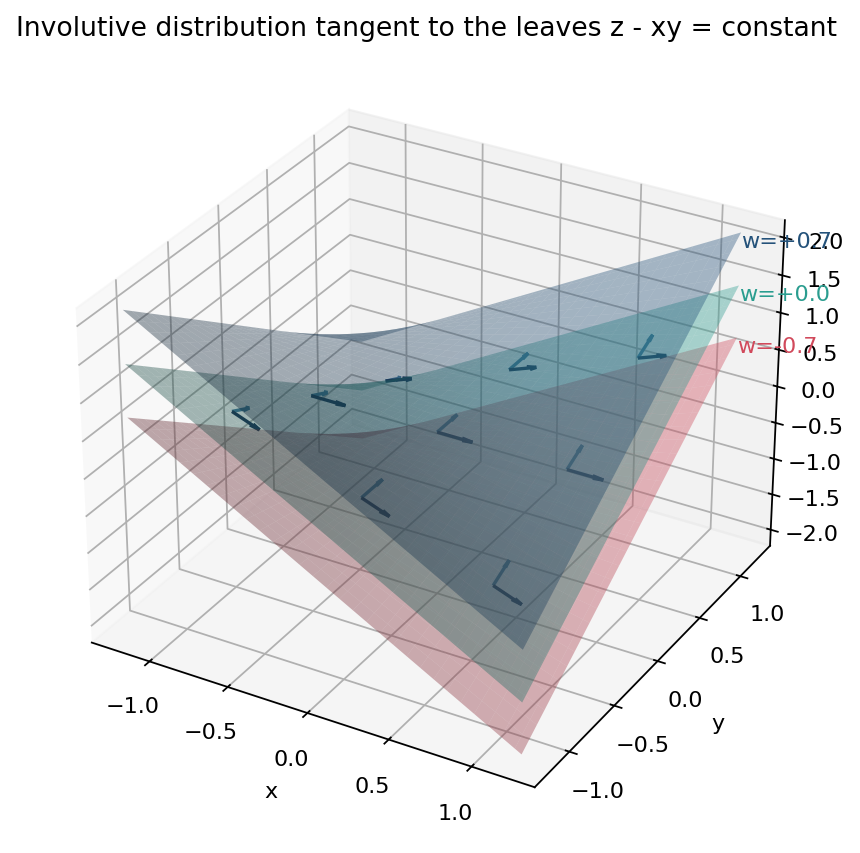

In [4]:
V_good = [1, 0, y]
W_good = [0, 1, x]
bracket_good = lie_bracket(V_good, W_good, coords)
w_expr = z - x * y
jacobian_flat = sp.Matrix([[sp.diff(expr, var) for var in coords] for expr in (x, y, w_expr)])
det_flat = sp.simplify(jacobian_flat.det())
alpha_good_on_V = sp.simplify(sp.diff(w_expr, x) * V_good[0] + sp.diff(w_expr, y) * V_good[1] + sp.diff(w_expr, z) * V_good[2])
alpha_good_on_W = sp.simplify(sp.diff(w_expr, x) * W_good[0] + sp.diff(w_expr, y) * W_good[1] + sp.diff(w_expr, z) * W_good[2])

xx = np.linspace(-1.2, 1.2, 60)
yy = np.linspace(-1.2, 1.2, 60)
XX, YY = np.meshgrid(xx, yy)
fig = plt.figure(figsize=(9.2, 6.4))
ax = fig.add_subplot(111, projection="3d")
for c, color in [(-0.7, "#d1495b"), (0.0, "#2a9d8f"), (0.7, "#24527a")]:
    ZZ = XX * YY + c
    ax.plot_surface(XX, YY, ZZ, alpha=0.38, color=color, linewidth=0)
    ax.text(1.25, 1.1, 1.25 * 1.1 + c, f"w={c:+.1f}", color=color)
sample_x = np.array([-0.8, 0.0, 0.8])
sample_y = np.array([-0.8, 0.0, 0.8])
SX, SY = np.meshgrid(sample_x, sample_y)
SZ = SX * SY
ax.quiver(SX, SY, SZ, np.ones_like(SX), np.zeros_like(SX), SY, length=0.22, normalize=True, color="#1d3557")
ax.quiver(SX, SY, SZ, np.zeros_like(SX), np.ones_like(SX), SX, length=0.22, normalize=True, color="#457b9d")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Involutive distribution tangent to the leaves z - xy = constant")
frobenius_path = save_matplotlib(fig, FIGURES / "frobenius-flat-chart-level-surfaces.png")
plt.close(fig)
artifacts.append(frobenius_path)

frobenius_check = save_json(
    {
        "V": [str(v) for v in V_good],
        "W": [str(v) for v in W_good],
        "bracket": [str(v) for v in bracket_good],
        "flat_chart": ["u=x", "v=y", "w=z-x*y"],
        "flat_jacobian_determinant": str(det_flat),
        "dw_on_V": str(alpha_good_on_V),
        "dw_on_W": str(alpha_good_on_W),
        "involutive_and_flat": bool(bracket_good == [0, 0, 0] and det_flat == 1 and alpha_good_on_V == 0 and alpha_good_on_W == 0),
    },
    CHECKS / "frobenius-flat-chart-level-surfaces.json",
)
check_paths.append(frobenius_check)
display_artifact(frobenius_path, width=820)

## 4. From Flat Charts To Foliations

A flat chart gives local plaques: slices with constant transverse coordinates. The global Frobenius theorem says that for an involutive distribution, maximal connected integral manifolds partition the whole manifold and form a foliation. The local plaques glue into leaves.

The diagram below represents three overlapping flat charts. The graph is not decorative: each edge means two plaques overlap in a way that puts them on the same maximal leaf.

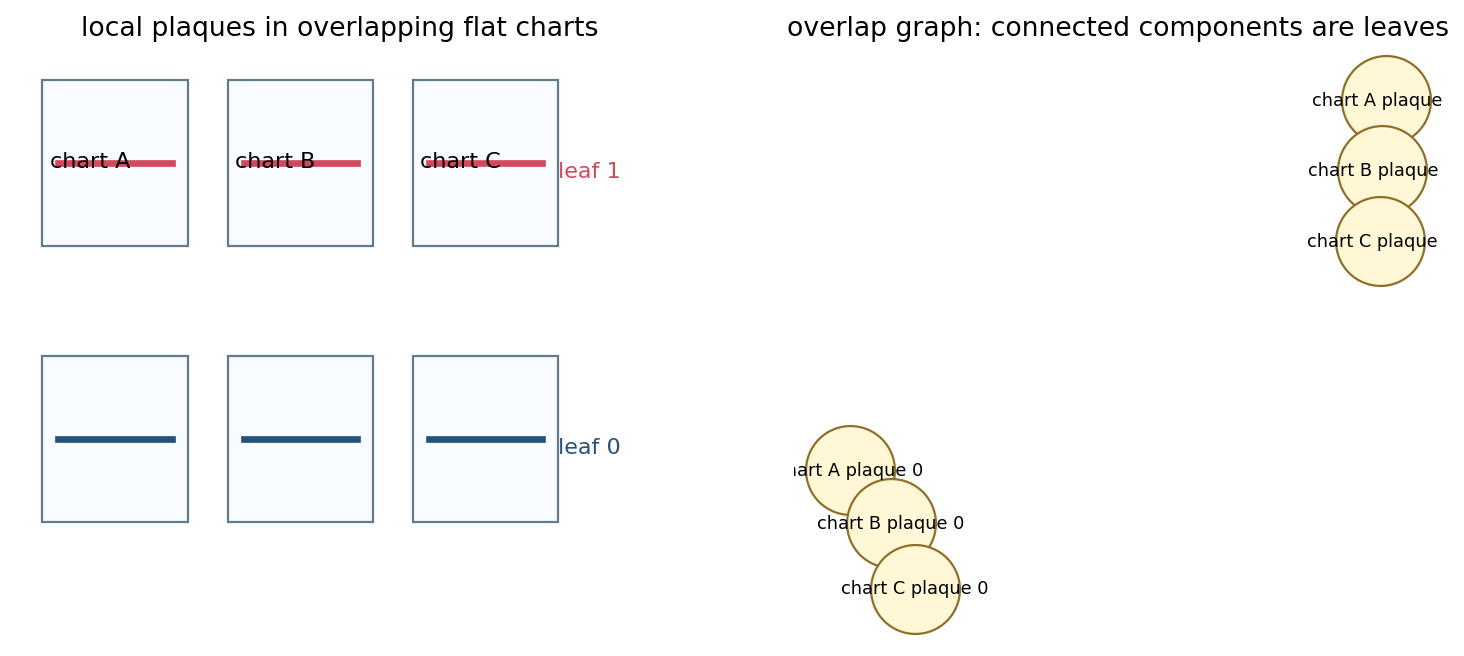

In [5]:
leaf_graph = nx.Graph()
leaf_graph.add_edges_from([
    ("chart A plaque 0", "chart B plaque 0"),
    ("chart B plaque 0", "chart C plaque 0"),
    ("chart A plaque 1", "chart B plaque 1"),
    ("chart B plaque 1", "chart C plaque 1"),
])
components = [sorted(component) for component in nx.connected_components(leaf_graph)]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.8))
for offset, color, label in [(-0.55, "#24527a", "leaf 0"), (0.15, "#d1495b", "leaf 1")]:
    for shift in [0.0, 0.7, 1.4]:
        rect = plt.Rectangle((shift, offset), 0.55, 0.42, facecolor="#f8fbff", edgecolor="#607d8b")
        ax0.add_patch(rect)
        ax0.plot([shift + 0.06, shift + 0.49], [offset + 0.21, offset + 0.21], color=color, lw=3)
    ax0.text(1.95, offset + 0.19, label, color=color, va="center")
ax0.text(0.18, 0.35, "chart A", ha="center")
ax0.text(0.88, 0.35, "chart B", ha="center")
ax0.text(1.58, 0.35, "chart C", ha="center")
ax0.set_xlim(-0.1, 2.35)
ax0.set_ylim(-0.85, 0.65)
ax0.axis("off")
ax0.set_title("local plaques in overlapping flat charts")

pos = nx.spring_layout(leaf_graph, seed=19)
nx.draw_networkx_edges(leaf_graph, pos, ax=ax1, edge_color="#607d8b")
nx.draw_networkx_nodes(leaf_graph, pos, ax=ax1, node_size=1600, node_color="#fff7d6", edgecolors="#8f6f2a")
nx.draw_networkx_labels(leaf_graph, pos, ax=ax1, font_size=8)
ax1.set_title("overlap graph: connected components are leaves")
ax1.axis("off")
foliation_path = save_matplotlib(fig, FIGURES / "global-frobenius-plaque-gluing.png")
plt.close(fig)
artifacts.append(foliation_path)

foliation_check = save_json(
    {
        "components": components,
        "component_count": len(components),
        "each_leaf_has_three_local_plaques": all(len(component) == 3 for component in components),
    },
    CHECKS / "global-frobenius-plaque-gluing.json",
)
check_paths.append(foliation_check)
display_artifact(foliation_path, width=920)

## 5. Lie Subalgebras Produce Lie Subgroups

For a Lie group `G`, a Lie subalgebra of `Lie(G)` determines a left-invariant involutive distribution. The global Frobenius theorem supplies the leaf through the identity, and that leaf is the connected Lie subgroup with the chosen Lie algebra.

The torus square below is a compact visual model. A rational slope line closes up; an irrational slope line keeps winding. Both are leaves of left-invariant line fields. The irrational line is a reminder that the resulting subgroup can be immersed in a subtle way, which is why the chapter carefully uses immersed and weakly embedded submanifolds.

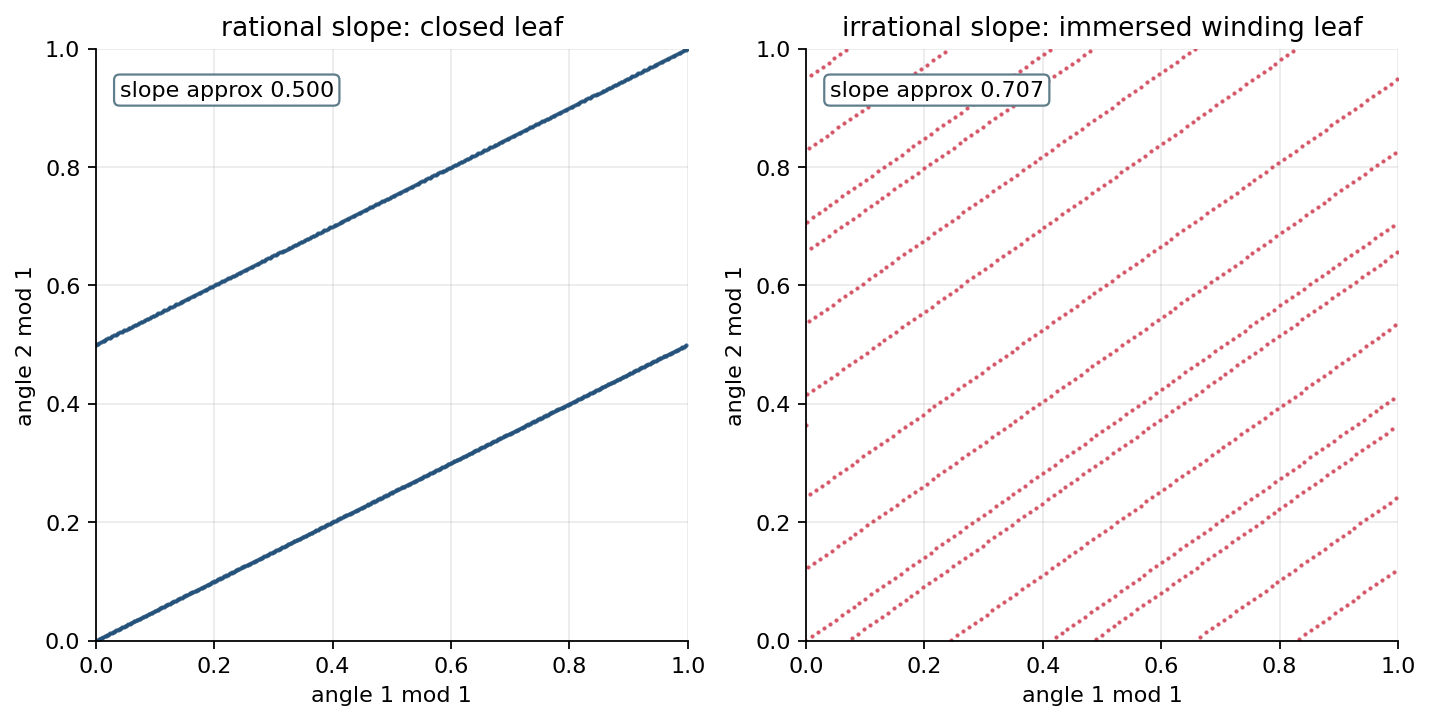

In [6]:
t_vals = np.linspace(0, 9, 900)
rational_slope = 1 / 2
irrational_slope = np.sqrt(2) / 2
rational_curve = np.column_stack((t_vals % 1, (rational_slope * t_vals) % 1))
irrational_curve = np.column_stack((t_vals % 1, (irrational_slope * t_vals) % 1))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 5))
for ax, curve, slope, title, color in [
    (ax0, rational_curve, rational_slope, "rational slope: closed leaf", "#24527a"),
    (ax1, irrational_curve, irrational_slope, "irrational slope: immersed winding leaf", "#d1495b"),
]:
    ax.plot(curve[:, 0], curve[:, 1], ".", color=color, markersize=1.8, alpha=0.85)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("angle 1 mod 1")
    ax.set_ylabel("angle 2 mod 1")
    ax.grid(alpha=0.25)
    ax.text(0.04, 0.92, f"slope approx {slope:.3f}", transform=ax.transAxes, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#607d8b"})
lie_path = save_matplotlib(fig, FIGURES / "lie-subalgebra-torus-line-leaves.png")
plt.close(fig)
artifacts.append(lie_path)

lie_rows = [
    {"model": "T2 rational line", "slope": rational_slope, "expected_leaf_behavior": "closed circle subgroup"},
    {"model": "T2 irrational line", "slope": float(irrational_slope), "expected_leaf_behavior": "immersed nonclosed winding subgroup"},
]
lie_table = save_csv(lie_rows, TABLES / "lie-subalgebra-torus-line-leaves.csv")
artifacts.append(lie_table)
lie_check = save_json(
    {
        "rows": lie_rows,
        "rational_sample_unique_grid_cells": int(len({tuple(np.floor(point * 20).astype(int)) for point in rational_curve})),
        "irrational_sample_unique_grid_cells": int(len({tuple(np.floor(point * 20).astype(int)) for point in irrational_curve})),
        "irrational_samples_more_cells": int(len({tuple(np.floor(point * 20).astype(int)) for point in irrational_curve})) > int(len({tuple(np.floor(point * 20).astype(int)) for point in rational_curve})),
    },
    CHECKS / "lie-subalgebra-torus-line-leaves.json",
)
check_paths.append(lie_check)
display_artifact(lie_path, width=880)

## 6. Overdetermined PDEs As Frobenius Problems

A first-order system such as

`u_x = alpha(x,y,u)`, `u_y = beta(x,y,u)`

asks for a graph surface tangent to the distribution spanned by

`X = partial_x + alpha partial_z`, and `Y = partial_y + beta partial_z`.

A solution with arbitrary initial value exists locally when the bracket stays in the span of `X` and `Y`. For scalar graph systems this becomes a cross-derivative compatibility condition. The two examples below show the difference between a compatible system and an incompatible one.

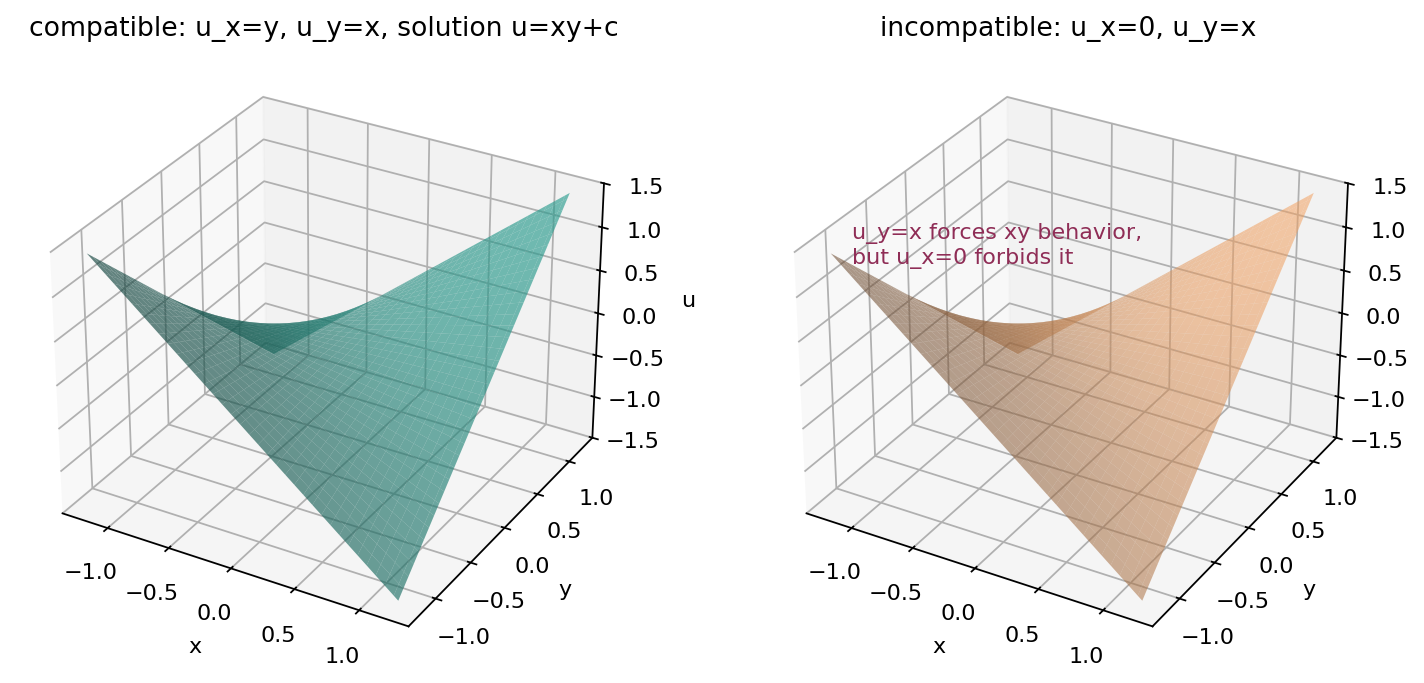

In [7]:
alpha_good = y
beta_good = x
alpha_bad = sp.Integer(0)
beta_bad = x

def pde_obstruction(alpha, beta):
    return sp.simplify(sp.diff(beta, x) + alpha * sp.diff(beta, z) - sp.diff(alpha, y) - beta * sp.diff(alpha, z))

obstruction_good = pde_obstruction(alpha_good, beta_good)
obstruction_bad = pde_obstruction(alpha_bad, beta_bad)

XX, YY = np.meshgrid(np.linspace(-1.2, 1.2, 70), np.linspace(-1.2, 1.2, 70))
ZZ_good = XX * YY
ZZ_bad_attempt = XX * YY  # satisfies u_y=x but not u_x=0

fig = plt.figure(figsize=(11, 5))
ax0 = fig.add_subplot(121, projection="3d")
ax0.plot_surface(XX, YY, ZZ_good, color="#2a9d8f", alpha=0.65, linewidth=0)
ax0.set_title("compatible: u_x=y, u_y=x, solution u=xy+c")
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_zlabel("u")

ax1 = fig.add_subplot(122, projection="3d")
ax1.plot_surface(XX, YY, ZZ_bad_attempt, color="#f4a261", alpha=0.55, linewidth=0)
ax1.text(-1.1, -1.1, 1.3, "u_y=x forces xy behavior,\nbut u_x=0 forbids it", color="#8f2d56")
ax1.set_title("incompatible: u_x=0, u_y=x")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u")
pde_path = save_matplotlib(fig, FIGURES / "frobenius-pde-compatibility-surfaces.png")
plt.close(fig)
artifacts.append(pde_path)

pde_rows = [
    {"system": "u_x=y, u_y=x", "obstruction": str(obstruction_good), "local_solution_model": "u=x*y+c"},
    {"system": "u_x=0, u_y=x", "obstruction": str(obstruction_bad), "local_solution_model": "no arbitrary local graph solution"},
]
pde_table = save_csv(pde_rows, TABLES / "frobenius-pde-compatibility.csv")
artifacts.append(pde_table)
pde_check = save_json(
    {
        "rows": pde_rows,
        "compatible_obstruction_zero": bool(obstruction_good == 0),
        "incompatible_obstruction_nonzero": bool(obstruction_bad != 0),
    },
    CHECKS / "frobenius-pde-compatibility-surfaces.json",
)
check_paths.append(pde_check)
display_artifact(pde_path, width=940)

## Applied Lab

Try these controlled changes:

- Replace `Y = partial_y` in the non-involutive example by `partial_y + x partial_z`. The bracket obstruction disappears and the leaves become `z - xy = constant`.
- Change the defining form from `dz - y dx` to `dz - y dx - x dy`. The latter is `d(z-xy)`, so its exterior derivative is zero and its kernel is integrable.
- Change the torus slope from rational to irrational. The local line field is still left-invariant, but the global leaf behavior changes.
- In the PDE model, make `alpha_y` and `beta_x` disagree. The surface plot may still show a candidate, but the bracket obstruction says it cannot satisfy both equations with arbitrary initial data.

These labs are the chapter in miniature: visual leaves are trustworthy only when the bracket or 1-form criterion has been checked.

## Final Sanity Checks

The final cell checks source-concept coverage, symbolic Frobenius invariants, artifact integrity, and the PDE compatibility examples.

In [8]:
coverage_terms = [
    "distribution",
    "integral manifold",
    "involutive",
    "Lie bracket",
    "1-form criterion",
    "Frobenius theorem",
    "flat chart",
    "foliation",
    "Lie subgroup",
    "overdetermined PDE",
]

assert bracket_bad == [0, 0, -1]
assert not bracket_in_span_bad
assert d_alpha_on_bad == 1
assert bracket_good == [0, 0, 0]
assert det_flat == 1
assert alpha_good_on_V == 0 and alpha_good_on_W == 0
assert len(components) == 2
assert obstruction_good == 0 and obstruction_bad != 0
assert_artifacts(artifacts + check_paths, min_bytes=64)

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 490-514",
    "coverage_terms": coverage_terms,
    "artifact_count": len(artifacts),
    "check_count": len(check_paths),
    "core_invariants": {
        "noninvolutive_bracket_escapes": not bracket_in_span_bad,
        "one_form_criterion_detects_failure": d_alpha_on_bad == 1,
        "frobenius_example_bracket_zero": bracket_good == [0, 0, 0],
        "flat_chart_jacobian": str(det_flat),
        "foliation_leaf_component_count": len(components),
        "pde_good_zero_bad_nonzero": bool(obstruction_good == 0 and obstruction_bad != 0),
    },
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
display(Markdown(f"Final sanity written to `{final_sanity_path.relative_to(BOOK_ROOT)}`."))
print("final_sanity passed for Chapter 19")

Final sanity written to `artifacts\chapter-19-distributions-and-foliations\checks\final_sanity.json`.

final_sanity passed for Chapter 19


## Takeaways

A distribution is a smoothly varying choice of tangent subspaces. Integral manifolds exist only when the distribution is closed under the Lie bracket, or equivalently when its annihilating forms generate a differential ideal. The Frobenius theorem says this necessary condition is sufficient: involutive distributions admit local flat charts, so their integral manifolds look locally like coordinate slices. The global theorem glues maximal connected integral manifolds into a foliation. The same mechanism explains why Lie subalgebras integrate to connected Lie subgroups and why certain overdetermined first-order PDE systems have local solutions exactly when their compatibility brackets vanish.